# Product Analytics using Python

In [1]:
# Loading dataset
import pandas as pd
pd.set_option('display.max_columns', None)
df = pd.read_excel('../../data/raw/Online Retail.xlsx', sheet_name='Online Retail')
df.shape

(541909, 8)

In [2]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
import janitor
df = df.clean_names(case_type='snake')

In [4]:
df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


<Axes: >

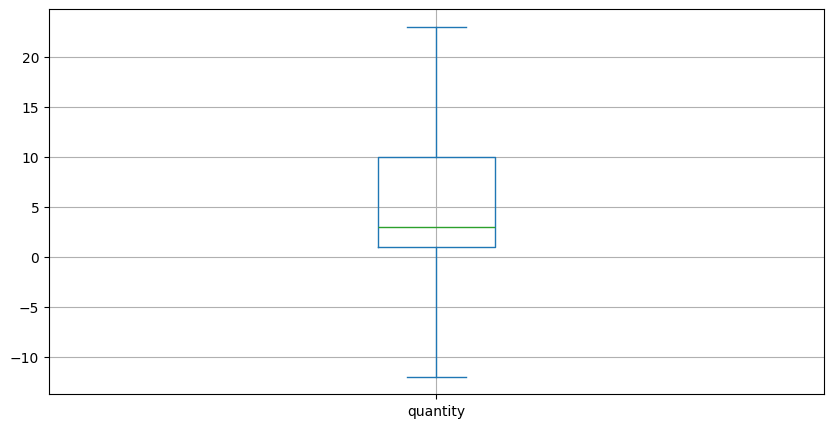

In [5]:
df['quantity'].plot.box(showfliers=False, grid=True, figsize=(10, 5))

In [6]:
# Screen out data Quantity > 0
df = df[df['quantity'] > 0]

<Axes: >

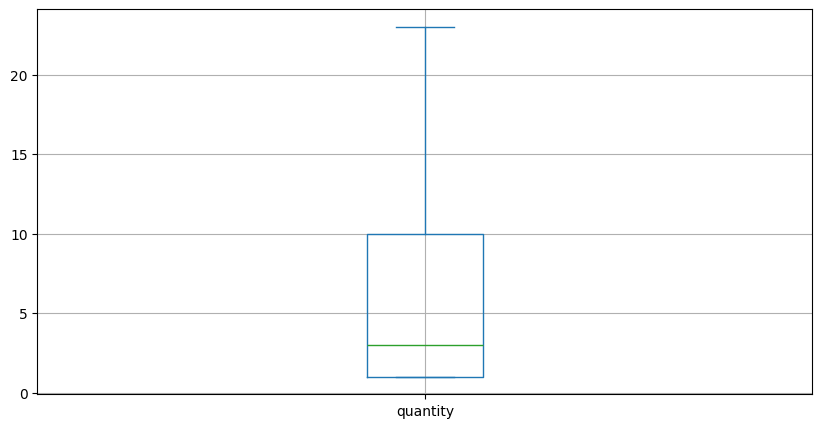

In [7]:
df['quantity'].plot.box(showfliers=False, grid=True, figsize=(10, 5))

# Visualize time series trend

In [8]:
monthly_orders_df = df.set_index('invoice_date')['invoice_no'].resample('ME').nunique()

In [9]:
monthly_orders_df

invoice_date
2010-12-31    1629
2011-01-31    1120
2011-02-28    1126
2011-03-31    1531
2011-04-30    1318
2011-05-31    1731
2011-06-30    1576
2011-07-31    1540
2011-08-31    1409
2011-09-30    1896
2011-10-31    2129
2011-11-30    2884
2011-12-31     839
Freq: ME, Name: invoice_no, dtype: int64

In [10]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=[x.strftime('%m.%Y') for x in monthly_orders_df.index],
    y=monthly_orders_df.values,
    mode='lines+markers'
))

fig.update_layout(
    title='Total Number of Orders Over Time',
    xaxis_title='date',
    yaxis_title='number of orders/invoices',
    xaxis=dict(tickangle=45),
    width=1000,
    height=700,
    template='ggplot2'
)

fig.show()

In [11]:
invoice_dates = df.loc[
    df['invoice_date'] >= '2011-12-01',
    'invoice_date'
]

In [13]:
print(f"Minimum invoice date: {invoice_dates.min()}")
print(f"Maximum invoice date: {invoice_dates.max()}")

Minimum invoice date: 2011-12-01 08:33:00
Maximum invoice date: 2011-12-09 12:50:00


In [14]:
# Filtering out data with invoice date < 2011-12-01
df = df[df['invoice_date'] < '2011-12-01']

In [15]:
# Create monthly orders dataframe
monthly_orders_df = df.set_index('invoice_date')['invoice_no'].resample('ME').nunique()
monthly_orders_df

invoice_date
2010-12-31    1629
2011-01-31    1120
2011-02-28    1126
2011-03-31    1531
2011-04-30    1318
2011-05-31    1731
2011-06-30    1576
2011-07-31    1540
2011-08-31    1409
2011-09-30    1896
2011-10-31    2129
2011-11-30    2884
Freq: ME, Name: invoice_no, dtype: int64

In [16]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=[x.strftime('%m.%Y') for x in monthly_orders_df.index],
    y=monthly_orders_df.values,
    mode='lines+markers'
))

fig.update_layout(
    title='Total Number of Orders Over Time',
    xaxis_title='date',
    yaxis_title='number of orders/invoices',
    xaxis=dict(tickangle=45),
    width=1000,
    height=700,
    template='ggplot2'
)

fig.show()

In [17]:
# Create monthly revenues dataframe
df['revenue'] = df['quantity'] * df['unit_price']
monthly_revenues_df = df.set_index('invoice_date')['revenue'].resample('ME').sum()
monthly_revenues_df

invoice_date
2010-12-31     823746.140
2011-01-31     691364.560
2011-02-28     523631.890
2011-03-31     717639.360
2011-04-30     537808.621
2011-05-31     770536.020
2011-06-30     761739.900
2011-07-31     719221.191
2011-08-31     737014.260
2011-09-30    1058590.172
2011-10-31    1154979.300
2011-11-30    1509496.330
Freq: ME, Name: revenue, dtype: float64

In [18]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=[x.strftime('%m.%Y') for x in monthly_revenues_df.index],
    y=monthly_revenues_df.values,
    mode='lines+markers',
    name='sales'
))

fig.update_layout(
    title='Total Revenue Over Time',
    xaxis_title='date',
    yaxis_title='sales',
    xaxis=dict(tickangle=45),
    yaxis=dict(range=[0, monthly_revenues_df.max() + 100000]),
    width=1000,
    height=700,
    template='ggplot2'
)

fig.show()

# Repeate Customer Behavior

In [19]:
# Create invoice_customer_df
invoice_customer_df = df.groupby(
    by=['invoice_no', 'invoice_date']
).agg({
    'revenue': sum,
    'customer_id': max,
    'country': max,
}).reset_index()

invoice_customer_df.head()

,invoice_no,invoice_date,revenue,customer_id,country
0,536365,2010-12-01 08:26:00,139.12,17850.0,United Kingdom
1,536366,2010-12-01 08:28:00,22.20,17850.0,United Kingdom
2,536367,2010-12-01 08:34:00,278.73,13047.0,United Kingdom
3,536368,2010-12-01 08:34:00,70.05,13047.0,United Kingdom
4,536369,2010-12-01 08:35:00,17.85,13047.0,United Kingdom


In [20]:
monthly_repeat_customers_df = invoice_customer_df.set_index('invoice_date').groupby([
                                                            pd.Grouper(freq='ME'), 'customer_id'
                                                            ]).filter(lambda x: len(x) > 1).resample('ME').nunique()['customer_id']
monthly_repeat_customers_df

invoice_date
2010-12-31    263
2011-01-31    153
2011-02-28    153
2011-03-31    203
2011-04-30    170
2011-05-31    281
2011-06-30    220
2011-07-31    227
2011-08-31    198
2011-09-30    272
2011-10-31    324
2011-11-30    541
Freq: ME, Name: customer_id, dtype: int64

In [21]:
monthly_unique_customers_df = df.set_index('invoice_date')['customer_id'].resample('ME').nunique()
monthly_unique_customers_df

invoice_date
2010-12-31     885
2011-01-31     741
2011-02-28     758
2011-03-31     974
2011-04-30     856
2011-05-31    1056
2011-06-30     991
2011-07-31     949
2011-08-31     935
2011-09-30    1266
2011-10-31    1364
2011-11-30    1665
Freq: ME, Name: customer_id, dtype: int64

In [22]:
monthly_repeat_percentage = monthly_repeat_customers_df/monthly_unique_customers_df*100.0
monthly_repeat_percentage

invoice_date
2010-12-31    29.717514
2011-01-31    20.647773
2011-02-28    20.184697
2011-03-31    20.841889
2011-04-30    19.859813
2011-05-31    26.609848
2011-06-30    22.199798
2011-07-31    23.919916
2011-08-31    21.176471
2011-09-30    21.484992
2011-10-31    23.753666
2011-11-30    32.492492
Freq: ME, Name: customer_id, dtype: float64

In [23]:
x_vals = monthly_repeat_customers_df.index

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x_vals,
    y=monthly_repeat_customers_df.values,
    mode='lines+markers',
    name='Repeat Customers'
))

fig.add_trace(go.Scatter(
    x=x_vals,
    y=monthly_unique_customers_df.values,
    mode='lines+markers',
    name='All Customers'
))

fig.add_trace(go.Bar(
    x=x_vals,
    y=monthly_repeat_percentage.values,
    name='Percentage of Repeat',
    marker_color='green',
    opacity=0.2,
    yaxis='y2'
))

fig.update_layout(
    title='Number of All vs. Repeat Customers Over Time',
    xaxis=dict(
        title='date',
        tickformat='%m.%Y',
        tickangle=45
    ),
    yaxis=dict(
        title='number of customers',
        range=[0, monthly_unique_customers_df.max() + 100]
    ),
    yaxis2=dict(
        title='percentage (%)',
        overlaying='y',
        side='right',
        range=[0, 100]
    ),
    width=1000,
    height=700,
    template='ggplot2',
    legend=dict(x=0.01, y=0.99)
)

fig.show()

# Trending Items over time

In [24]:
date_item_df = pd.DataFrame(
    df.set_index('invoice_date').groupby([
        pd.Grouper(freq='ME'), 'stock_code'
    ])['quantity'].sum()
)
date_item_df

quantity
invoice_date stock_code          
2010-12-31   10002            251
             10120             16
             10125            154
             10133            130
             10135            411
...                           ...
2011-11-30   C2               173
             DCGSSGIRL          1
             DOT               47
             M               3894
             POST            1262

[31701 rows x 1 columns]

In [25]:
# Rank items by the last month sales
last_month_sorted_df = date_item_df.loc['2011-11-30'].sort_values(
    by='quantity', ascending=False
).reset_index()

last_month_sorted_df

,stock_code,quantity
0,23084,14954
1,84826,12551
2,22197,12460
3,22086,7908
4,85099B,5909
...,...,...
2941,84549,1
2942,84527,1
2943,90082B,1
2944,90082D,1


In [26]:
# Regroup for top 5 items
date_item_df = pd.DataFrame(
    df.loc[
        df['stock_code'].isin([23084, 84826, 22197, 22086, '85099B'])
    ].set_index('invoice_date').groupby([
        pd.Grouper(freq='ME'), 'stock_code'
    ])['quantity'].sum()
)
date_item_df

quantity
invoice_date stock_code          
2010-12-31   22086           2460
             22197           2738
             84826            366
             85099B          2152
2011-01-31   22086             24
             22197           1824
             84826            480
             85099B          2747
2011-02-28   22086              5
             22197           2666
             84826             66
             85099B          3080
2011-03-31   22086             87
             22197           2803
             84826             60
             85099B          5282
2011-04-30   22086             13
             22197           1869
             84826              1
             85099B          2456
2011-05-31   22086             17
             22197           6849
             23084           1131
             85099B          3621
2011-06-30   22086            344
             22197           2095
             23084           1713
             84826              4
             85099B          3682
2011-07-31   22086            383
             22197           1876
             23084            318
             84826              2
             85099B          3129
2011-08-31   22086            490
             22197           5421
             23084           2267
             84826             72
             85099B          5502
2011-09-30   22086           2106
             22197           4196
             23084            680
             85099B          4401
2011-10-31   22086           3429
             22197           5907
             23084           6348
             84826             11
             85099B          5412
2011-11-30   22086           7908
             22197          12460
             23084          14954
             84826          12551
             85099B          5909

In [27]:
trending_itmes_df = date_item_df.reset_index().pivot(
	index='invoice_date',
	columns='stock_code',
	values='quantity'
).fillna(0)

trending_itmes_df

stock_code,22086,22197,23084,84826,85099B
invoice_date,,,,,
2010-12-31,2460.0,2738.0,0.0,366.0,2152.0
2011-01-31,24.0,1824.0,0.0,480.0,2747.0
2011-02-28,5.0,2666.0,0.0,66.0,3080.0
2011-03-31,87.0,2803.0,0.0,60.0,5282.0
2011-04-30,13.0,1869.0,0.0,1.0,2456.0
2011-05-31,17.0,6849.0,1131.0,0.0,3621.0
2011-06-30,344.0,2095.0,1713.0,4.0,3682.0
2011-07-31,383.0,1876.0,318.0,2.0,3129.0
2011-08-31,490.0,5421.0,2267.0,72.0,5502.0


In [28]:
fig = go.Figure()

for col in trending_itmes_df.columns:
    fig.add_trace(go.Scatter(
        x=trending_itmes_df.index,
        y=trending_itmes_df[col],
        mode='lines+markers',
        name=str(col)
    ))

fig.update_layout(
    title='Item Trends over Time',
    xaxis_title='date',
    yaxis_title='number of purchases',
    xaxis=dict(
        tickformat='%m.%Y',
        tickangle=45
    ),
    width=1000,
    height=700,
    template='ggplot2'
)

fig.show()

In [32]:
df.query('stock_code == 84826')


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,revenue
3323,536620,84826,ASSTD DESIGN 3D PAPER STICKERS,60,2010-12-02 10:27:00,0.85,14135.0,United Kingdom,51.00
29521,538801,84826,ASSTD DESIGN 3D PAPER STICKERS,60,2010-12-14 11:51:00,0.21,16083.0,United Kingdom,12.60
30536,538870,84826,ASSTD DESIGN 3D PAPER STICKERS,60,2010-12-14 14:54:00,0.21,12829.0,United Kingdom,12.60
31105,538895,84826,ASSTD DESIGN 3D PAPER STICKERS,60,2010-12-15 09:07:00,0.21,14401.0,United Kingdom,12.60
31991,539038,84826,ASSTD DESIGN 3D PAPER STICKERS,60,2010-12-15 14:45:00,0.21,15641.0,United Kingdom,12.60
32254,539050,84826,ASSTD DESIGN 3D PAPER STICKERS,2,2010-12-15 16:21:00,0.85,12577.0,France,1.70
37613,539472,84826,ASSTD DESIGN 3D PAPER STICKERS,1,2010-12-19 14:23:00,0.85,15581.0,United Kingdom,0.85
37615,539472,84826,ASSTD DESIGN 3D PAPER STICKERS,1,2010-12-19 14:23:00,0.85,15581.0,United Kingdom,0.85
37621,539472,84826,ASSTD DESIGN 3D PAPER STICKERS,2,2010-12-19 14:23:00,0.85,15581.0,United Kingdom,1.70
41236,539761,84826,ASSTD DESIGN 3D PAPER STICKERS,60,2010-12-22 10:29:00,0.21,17593.0,United Kingdom,12.60
